# 🧠 APVC – Desafio 2
## Redes neuronais convolucionais para distinguir cães de gatos

### 👥 Grupo G11
- **Bernardo Coelho**, nº 98445  
- **Rafael Alexandre Dias Andorinha**, nº 131000  
- **Nuno Martins**, nº 98863  
- **Pedro Fonte Santa**, nº 105306  

---

📅 **Data de entrega:** 30 de março  

📊 **Objetivo deste script:** O presente script tem como objetivo principal o desenvolvimento de uma solução baseada em redes neuronais convolucionais (CNNs) para a classificação binária de imagens de cães e gatos, no âmbito do **Desafio 2 da unidade curricular de Análise e Processamento de Visão por Computador (APVC)**.

A implementação encontra-se dividida em duas Partes:


---

# 📌 Parte 1:

Numa primeira fase, foi realizado o carregamento e preparação do dataset **"Cats and Dogs"**, disponibilizado via Moodle, esta parte é composta por:


### ✅ Passo 1: Descarregar o Dataset
O primeiro passo consiste em descarregar o dataset **"Cats and Dogs"** disponibilizado no Moodle, que contém 2.000 imagens de treino (1.000 cães e 1.000 gatos) e 1.000 imagens de validação (500 cães e 500 gatos).

In [1]:
# importes usados

import tensorflow as tf
import numpy as np
import random
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.utils import split_dataset
import os
from PIL import Image


2025-03-26 12:23:32.801800: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
dataset_path = '../cats_and_dogs/'

# Carregar as imagens de treino
train_dataset = image_dataset_from_directory(
    directory=f'{dataset_path}/train',
    image_size=(150, 150),  # Ajustar as imagens para 150x150
    batch_size=32,  # Tamanho do lote
    label_mode='int',  # Classificação binária (0 para cães, 1 para gatos)
    shuffle=True  # Embaralhar os dados
)

# Carregar as imagens de validação
val_dataset = image_dataset_from_directory(
    directory=f'{dataset_path}/validation',
    image_size=(150, 150),  # Ajustar as imagens para 150x150
    batch_size=32,  # Tamanho do lote
    label_mode='int',  # Classificação binária
    shuffle=True  # Embaralhar os dados
)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


### ✅ Passo 2: Dividir o Conjunto de Validação
O conjunto de validação que temos (1.000 imagens) deve ser dividido em dois novos conjuntos:
1. **Validação** – 500 imagens (250 cães + 250 gatos)
2. **Teste** – 500 imagens (250 cães + 250 gatos)

In [3]:
# Extrair todas as imagens e labels para listas
all_images = []
all_labels = []

for batch in val_dataset:
    images, labels = batch
    all_images.extend(images)
    all_labels.extend(labels)

# Combinar imagens e labels
dados = list(zip(all_images, all_labels))

# Embaralhar de forma reprodutível
random.seed(42)
random.shuffle(dados)

# Separar novamente
all_images, all_labels = zip(*dados)

# Converter para tensores
all_images = tf.stack(all_images)
all_labels = tf.stack(all_labels)

# Dividir em 500 para validação e 500 para teste
val_images = all_images[:500]
val_labels = all_labels[:500]

test_images = all_images[500:]
test_labels = all_labels[500:]

# Criar datasets
val_dataset = tf.data.Dataset.from_tensor_slices((val_images, val_labels)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((test_images, test_labels)).batch(32)

2025-03-26 12:25:20.227616: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### ✅ Passo 3: Verificar a Distribuição das Classes

Confirmamos que temos cerca de 250 cães e 250 gatos em cada conjunto.

In [4]:
def contar_classes(dataset, nome="Conjunto"):
    labels = []
    for _, batch_labels in dataset:
        labels.extend(batch_labels.numpy())
    labels = np.array(labels)
    n_caes = np.sum(labels == 0)
    n_gatos = np.sum(labels == 1)
    print(f"{nome} - Cães: {n_caes}, Gatos: {n_gatos}")

contar_classes(val_dataset, "Validação")
contar_classes(test_dataset, "Teste")

2025-03-26 12:25:29.193534: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Validação - Cães: 236, Gatos: 264
Teste - Cães: 264, Gatos: 236


2025-03-26 12:25:29.447156: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


# 📌 Parte 2:

# Decisões tomadas

---

Na segunda fase, foi desenvolvida uma **rede convolucional personalizada**, com o objetivo de classificar imagens em duas categorias: **Cão** ou **Gato**.  
A arquitetura definida inclui:

- Três camadas convolucionais com pooling
- Camadas densas
- Regularização através da técnica de **Dropout**
- Camada final com activação `sigmoid` para classificação binária

Foram aplicadas técnicas específicas para mitigar o **overfitting**, nomeadamente:

- **Dropout** na camada densa final, para reduzir dependência excessiva de determinados neurónios
- **EarlyStopping**, que pára o treino automaticamente se a performance em validação não melhorar após um número definido de épocas
- **ModelCheckpoint**, que assegura que os melhores pesos (com menor `val_loss`) são guardados durante o treino

Além disso, foi feita a **normalização dos dados de entrada** com `Rescaling(1./255)`, permitindo converter os valores dos píxeis para o intervalo `[0, 1]`, garantindo estabilidade e eficiência no processo de treino.

O modelo foi treinado com:
- Imagens redimensionadas para `(150, 150)`
- `batch_size = 32`
- Função de perda `binary_crossentropy`
- Otimizador `Adam`

Foi feito ainda na preparação dos dados para treino através da extração dos tensores de imagem e respetivos rótulos dos datasets criados com image_dataset_from_directory.
Esta transformação permitiu converter os datasets de treino e validação em tuplos do tipo (x, y), compatíveis com a função model.fit(...) utilizada para o treino da rede.

A performance foi avaliada através de:
- Métricas visuais (gráficos de loss e accuracy)
- Matriz de confusão no conjunto de teste
- Análise de previsões com imagens reais dos membros do grupo

---

In [5]:
# imports usados

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os
from tensorflow.keras.utils import load_img, img_to_array

In [6]:
# Definir a arquitectura da rede convolucional "custom"
model = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(150, 150, 3)),  # Normalização dos pixels para [0,1]

    # Primeira camada convolucional + max pooling
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Segunda camada convolucional + max pooling
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Terceira camada convolucional + max pooling
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten + Dense + Dropout
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # Redução de overfitting

    # Camada de saída para classificação binária
    layers.Dense(1, activation='sigmoid')
])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### ⚙️ Compilação do Modelo

Vamos compilar o modelo com:
- **Binary Crossentropy** como função de perda (problema binário)
- **Adam** como optimizador (adaptativo e eficiente)
- **Accuracy** como métrica de desempenho

In [7]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### 📦 Preparação dos Dados para o Treino

Transformamos os datasets de treino e validação em tuplos de (x, y) para compatibilidade com `model.fit()`.


In [8]:
# Extrair todos os batches para arrays (modo eager para compatibilidade com .fit)
def dataset_para_xy(dataset):
    x, y = [], []
    for batch_imgs, batch_labels in dataset:
        x.extend(batch_imgs.numpy())
        y.extend(batch_labels.numpy())
    return tf.convert_to_tensor(x), tf.convert_to_tensor(y)

x_train, y_train = dataset_para_xy(train_dataset)
x_val, y_val = dataset_para_xy(val_dataset)

2025-03-26 12:25:50.103646: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-03-26 12:27:40.479736: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### 🧠 Treino do Modelo com Callbacks

Vamos agora treinar o modelo usando:
- **EarlyStopping**: para parar o treino se não houver melhorias na validação
- **ModelCheckpoint**: para guardar os melhores pesos em `tmp/best_model.weights.h5`

In [9]:
# Definir os callbacks (iguais ao do Desafio 1)
BEST_MODEL_CHECKPOINT = keras.callbacks.ModelCheckpoint(
    filepath="tmp/best_model.weights.h5",
    save_weights_only=True,
    monitor='val_loss',
    mode='min',
    save_best_only=True
)

EARLY_STOPPING = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5
)

# Treinar o modelo
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(x_val, y_val),
    callbacks=[BEST_MODEL_CHECKPOINT, EARLY_STOPPING],
    verbose=2
)

Epoch 1/50
63/63 - 77s - 1s/step - accuracy: 0.5210 - loss: 0.7053 - val_accuracy: 0.5280 - val_loss: 0.6947
Epoch 2/50
63/63 - 80s - 1s/step - accuracy: 0.5880 - loss: 0.6818 - val_accuracy: 0.6640 - val_loss: 0.6404
Epoch 3/50
63/63 - 71s - 1s/step - accuracy: 0.6420 - loss: 0.6299 - val_accuracy: 0.7100 - val_loss: 0.5751
Epoch 4/50
63/63 - 85s - 1s/step - accuracy: 0.7185 - loss: 0.5539 - val_accuracy: 0.7240 - val_loss: 0.5535
Epoch 5/50
63/63 - 70s - 1s/step - accuracy: 0.7645 - loss: 0.4995 - val_accuracy: 0.6760 - val_loss: 0.6016
Epoch 6/50
63/63 - 68s - 1s/step - accuracy: 0.7835 - loss: 0.4624 - val_accuracy: 0.7220 - val_loss: 0.5671
Epoch 7/50
63/63 - 67s - 1s/step - accuracy: 0.8270 - loss: 0.3778 - val_accuracy: 0.7160 - val_loss: 0.6342
Epoch 8/50
63/63 - 67s - 1s/step - accuracy: 0.8390 - loss: 0.3394 - val_accuracy: 0.7360 - val_loss: 0.6332
Epoch 9/50
63/63 - 72s - 1s/step - accuracy: 0.8945 - loss: 0.2484 - val_accuracy: 0.6960 - val_loss: 0.7438


### 📊 Evolução da Loss e Accuracy Durante o Treino

Visualizamos os resultados guardados no `history` para analisar o desempenho do modelo ao longo das épocas.

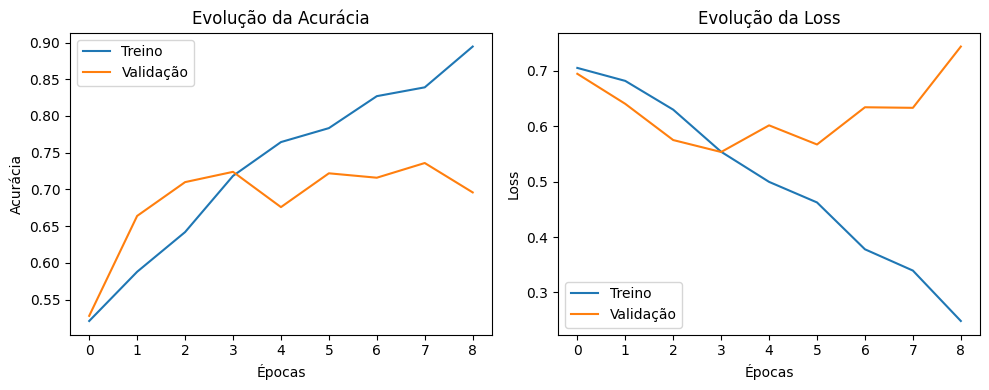

In [10]:
# Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Evolução da Acurácia')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Evolução da Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### 🔀 Matriz de Confusão (Conjunto de Teste)

Vamos agora verificar onde o modelo está a confundir cães e gatos, utilizando uma **matriz de confusão**.

2025-03-26 14:21:24.350812: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 288ms/step - accuracy: 0.7123 - loss: 0.5649
Taxa de acertos no conjunto de teste: 72.80%
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 294ms/step


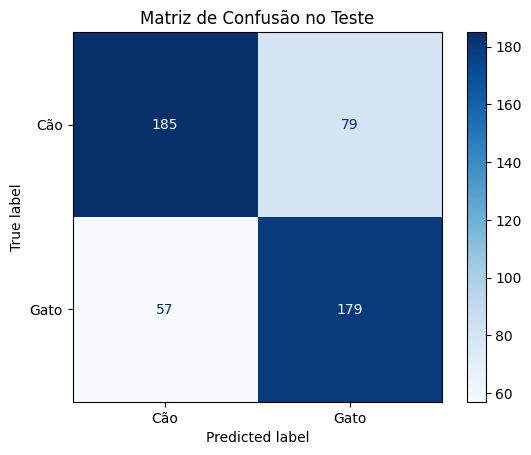

In [11]:
# Carregar os melhores pesos
model.load_weights("tmp/best_model.weights.h5")

# Extrair imagens e labels do conjunto de teste
x_test, y_test = dataset_para_xy(test_dataset)

# Avaliar o modelo no conjunto de teste
test_loss, test_accuracy = model.evaluate(x_test, y_test)

# Mostrar a taxa de acertos
print(f"Taxa de acertos no conjunto de teste: {test_accuracy * 100:.2f}%")

# Fazer previsões
y_pred_prob = model.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Gerar matriz de confusão
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Cão", "Gato"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão no Teste")
plt.show()

---

## 🧑‍🎓🐕 Classificação de Fotos dos Membros do Grupo

Nesta secção final vamos testar o modelo com **imagens reais** dos animais de estimação dos membros do grupo.  
Estas imagens **não fazem parte do dataset original**, o que permite verificar se o modelo generaliza bem para novos dados.

In [7]:
# imports usados

from PIL import Image
import os

In [3]:
# Esta função serve para verificar se alguma imagem está corrompida antes de usar
def verificar_imagens_validas(pasta):
    erros = 0
    extensoes_validas = (".jpg", ".jpeg", ".png")

    for subdir, _, files in os.walk(pasta):
        for file in files:
            # Ignorar ficheiros que não são imagens válidas
            if not file.lower().endswith(extensoes_validas):
                continue

            caminho = os.path.join(subdir, file)
            try:
                with Image.open(caminho) as img:
                    img.verify()  # Verifica se é uma imagem válida
            except Exception as e:
                print(f"[ERRO] {caminho}: {e}")
                erros += 1

    print(f"\nVerificação concluída. {erros} ficheiro(s) inválido(s) encontrados na pasta {pasta}.")

In [10]:
# Criar dataset com as fotos reais dos membros do grupo
grupo_dataset = image_dataset_from_directory(
    directory=f"{dataset_path}/fotos_grupo",
    image_size=(150, 150),  # mesmo tamanho usado no treino!
    batch_size=1,
    shuffle=False  # manter ordem das imagens
)

# Obter nomes das classes (ex: ['cats', 'dogs'])
grupo_class_names = grupo_dataset.class_names
print("Ordem das classes no dataset do grupo:", grupo_class_names)

# Carregar os pesos do melhor modelo
model.load_weights("tmp/best_model.weights.h5")

# Fazer previsões em todas as imagens do grupo
for batch in grupo_dataset:
    imagens, labels_reais = batch
    previsao = model.predict(imagens)[0][0]

    # Determinar classe prevista e confiança
    if previsao < 0.5:
        classe_prevista = "Gato"
        confianca = (1 - previsao) * 100
    else:
        classe_prevista = "Cão"
        confianca = previsao * 100

    # Determinar classe real
    classe_real = "Gato" if labels_reais[0].numpy() == 0 else "Cão"

    # Mostrar a imagem e o resultado
    plt.imshow(imagens[0].numpy().astype("uint8"))
    plt.axis("off")
    plt.title(f"Verdadeiro: {classe_real} | Previsto: {classe_prevista} ({confianca:.1f}%)")
    plt.show()

Found 18 files belonging to 2 classes.


Ordem das classes no dataset do grupo: ['cats', 'dogs']


NameError: name 'model' is not defined